Using device: cuda
Dataset shape: (20640, 8), target shape: (20640,)
RegressionMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Epoch [20/200] | Train Loss: 0.3910 | Val Loss: 0.3436
Epoch [40/200] | Train Loss: 0.3387 | Val Loss: 0.3182
Epoch [60/200] | Train Loss: 0.3182 | Val Loss: 0.2969
Epoch [80/200] | Train Loss: 0.3105 | Val Loss: 0.2962
Early stopping triggered at epoch 98
Training finished.

--- Test Set Evaluation ---
RMSE: 0.5323 (in units of $100,000)
R² Score: 0.7838


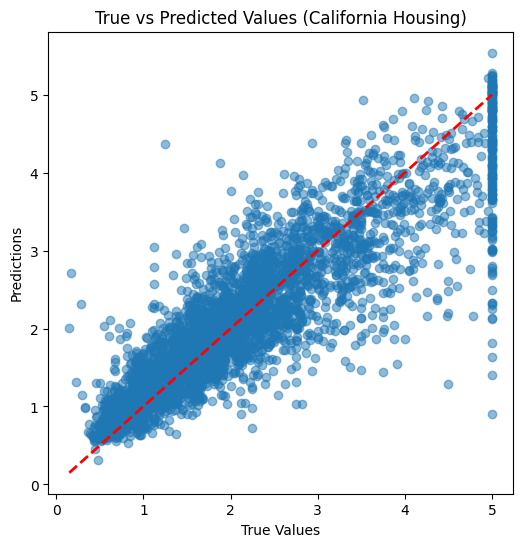

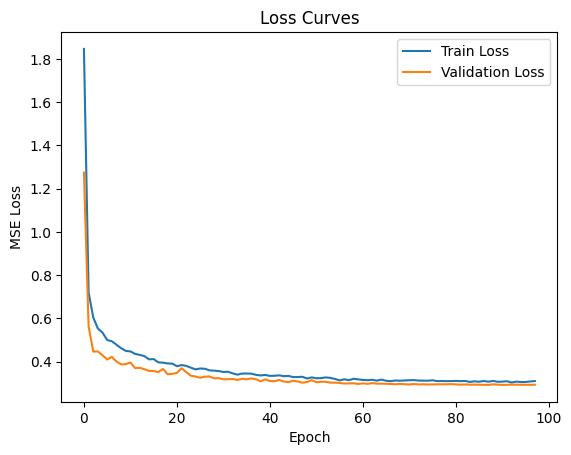

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# ============================
# 1. Set device
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ============================
# 2. Load and preprocess data
# ============================
data = fetch_california_housing()
X = data.data          # Features: 8 columns
y = data.target        # Target: median house value (in $100,000)

print(f"Dataset shape: {X.shape}, target shape: {y.shape}")

# Split into train+val and test sets (80/20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Further split train+val into train (80% of total) and validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)  # This yields 60% train, 20% val, 20% test of original data

# Standardize features (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)  # reshape to (n_samples, 1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create TensorDatasets and DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ============================
# 3. Define the regression model
# ============================
class RegressionMLP(nn.Module):
    def __init__(self, input_size=8, hidden_sizes=[64, 32], dropout_prob=0.2):
        super(RegressionMLP, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))   # Optional: helps generalization
            prev_size = hidden_size
        # Output layer: 1 neuron, no activation (linear)
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

model = RegressionMLP().to(device)
print(model)

# ============================
# 4. Loss function, optimizer, scheduler
# ============================
criterion = nn.MSELoss()          # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ============================
# 5. Early stopping setup
# ============================
early_stop_patience = 10
best_val_loss = float('inf')
patience_counter = 0
best_model_path = 'best_regression_model.pth'

# ============================
# 6. Training loop with validation
# ============================
num_epochs = 200
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Scheduler step based on validation loss
    scheduler.step(epoch_val_loss)

    # Early stopping check
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    if (epoch+1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

print("Training finished.")

# ============================
# 7. Load best model and evaluate on test set
# ============================
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_predictions = []
test_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        test_predictions.append(outputs.cpu().numpy())
        test_targets.append(targets.cpu().numpy())

# Concatenate batches
y_pred = np.concatenate(test_predictions, axis=0).flatten()
y_true = np.concatenate(test_targets, axis=0).flatten()

# Compute regression metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("\n--- Test Set Evaluation ---")
print(f"RMSE: {rmse:.4f} (in units of $100,000)")
print(f"R² Score: {r2:.4f}")

# ============================
# 8. Plot true vs predicted values
# ============================
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True vs Predicted Values (California Housing)')
plt.show()

# Optional: plot loss curves
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Loss Curves')
plt.show()